In [19]:
import sys
sys.path.insert(0, "..")

import joblib

import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from loguru import logger

pd.set_option("display.max_columns", None)

In [20]:
from src.evaluation.metrics import build_predictions_report

In [21]:
def plot_barh_by_model(results_df, x, y="model", hue=None, title="", figsize=(8, 6)):
    """Barplot horizontal genérico para comparar modelos por una métrica."""
    df_sorted = results_df.sort_values(x, ascending=True)
    fig, ax = plt.subplots(figsize=figsize)
    sns.barplot(df_sorted, x=x, y=y, hue=hue, order=df_sorted[y], ax=ax)
    ax.set_title(title, loc="left", pad=20)
    ax.set_xlabel("")
    ax.set_ylabel("")
    sns.despine()
    if hue:
        ax.legend(title=hue, loc="upper right")
    plt.tight_layout()
    plt.show()

In [22]:
LEVEL = 'level_09_daily_store_dept'

In [ ]:
import joblib

artifact_path = f"../artifacts/{LEVEL}_artifact.pkl"
artifact = joblib.load(artifact_path)

model = artifact["model"]
X_test, y_test = artifact["X_test"], artifact["y_test"]
FEATURES = artifact["features"]
feature_importance = artifact["feature_importance"]
results_df = artifact["results_df"]

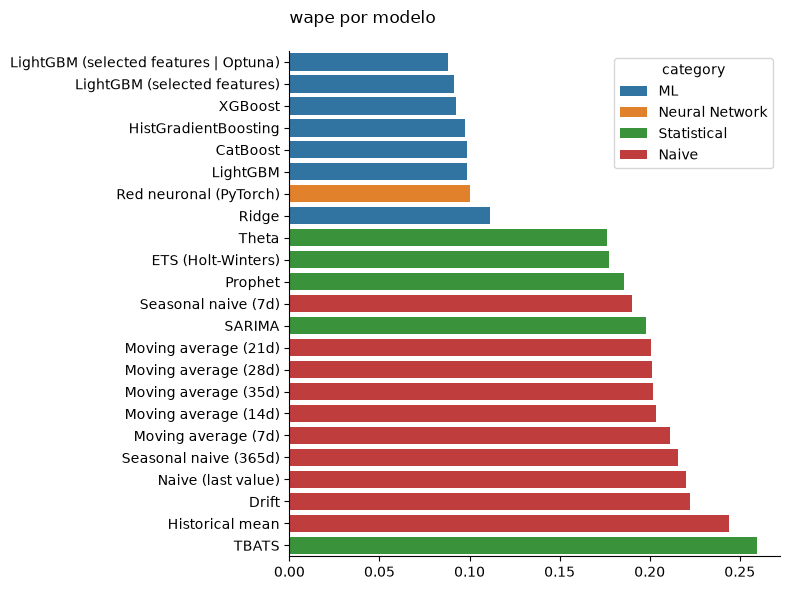

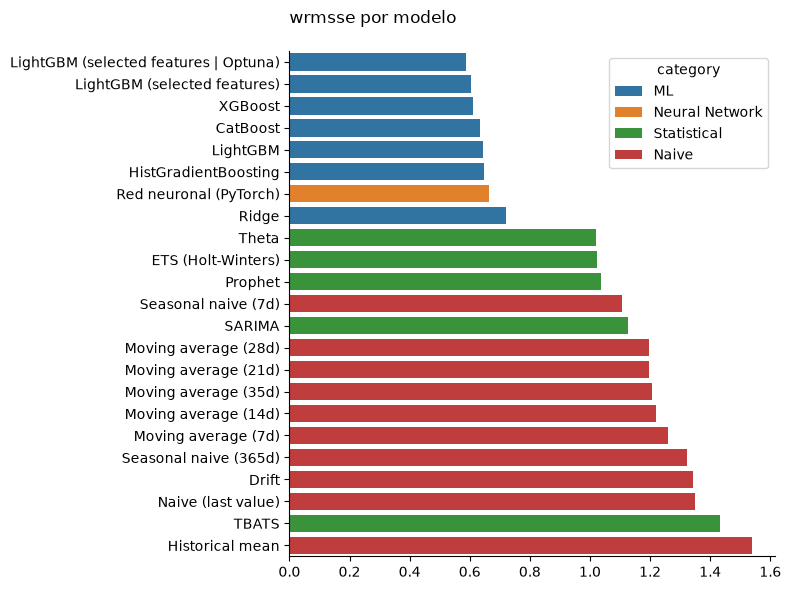

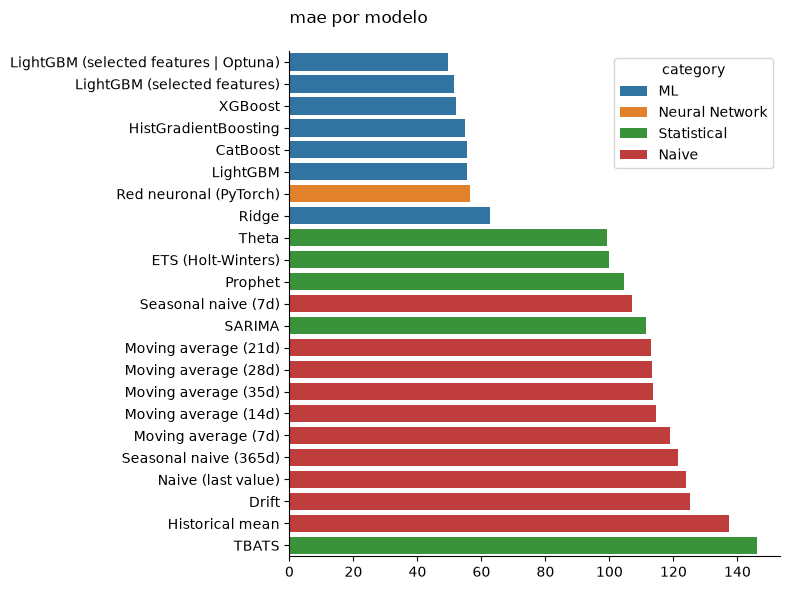

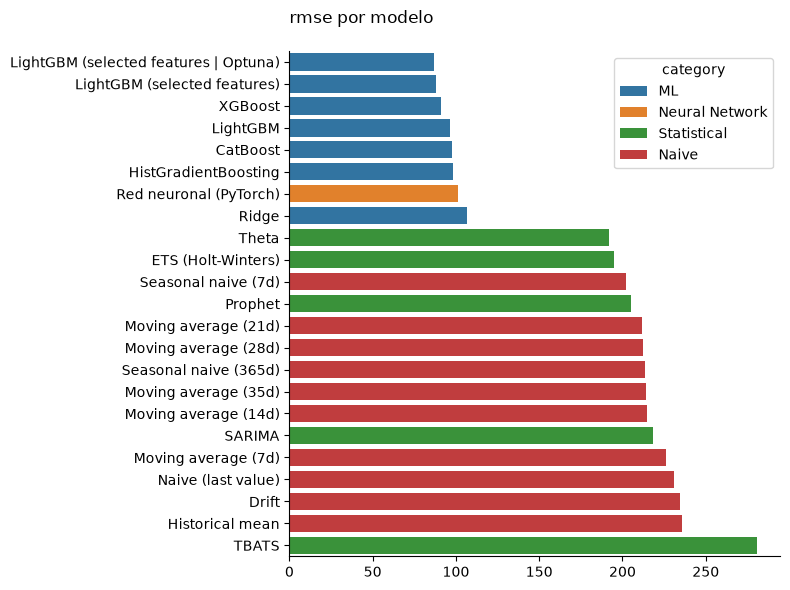

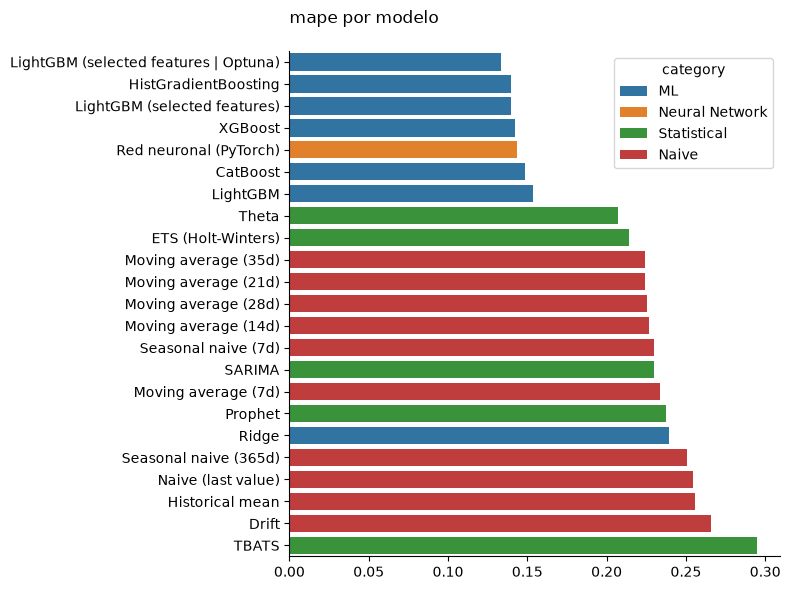

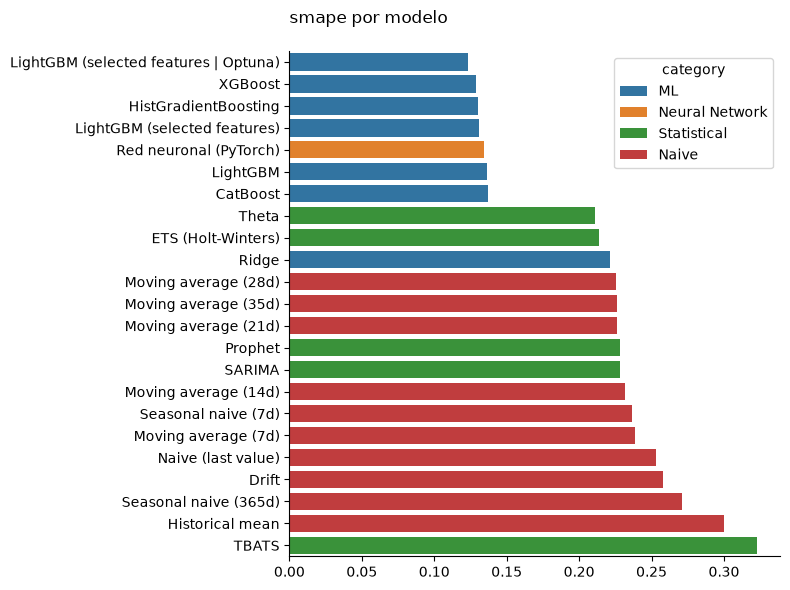

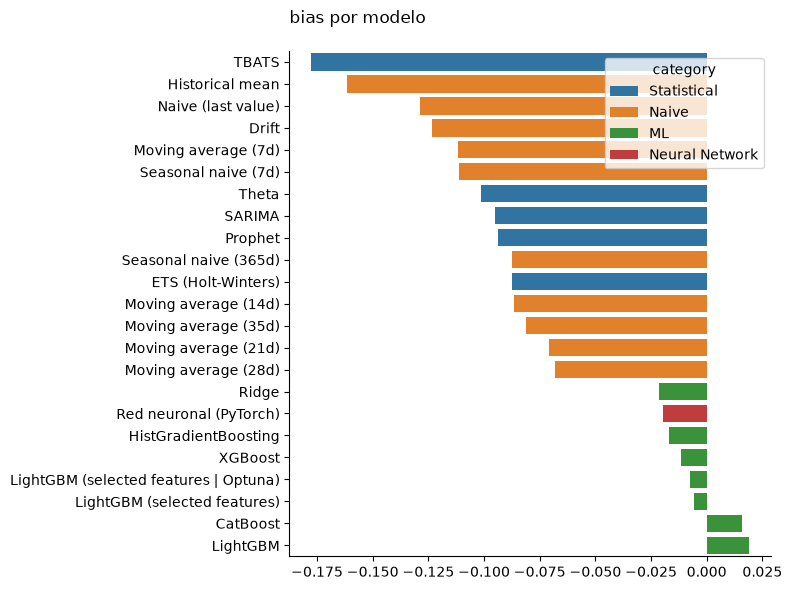

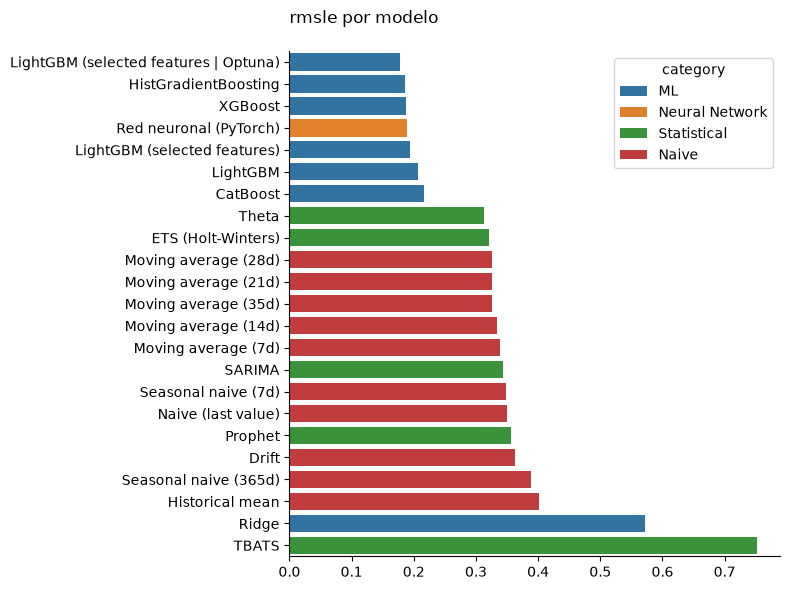

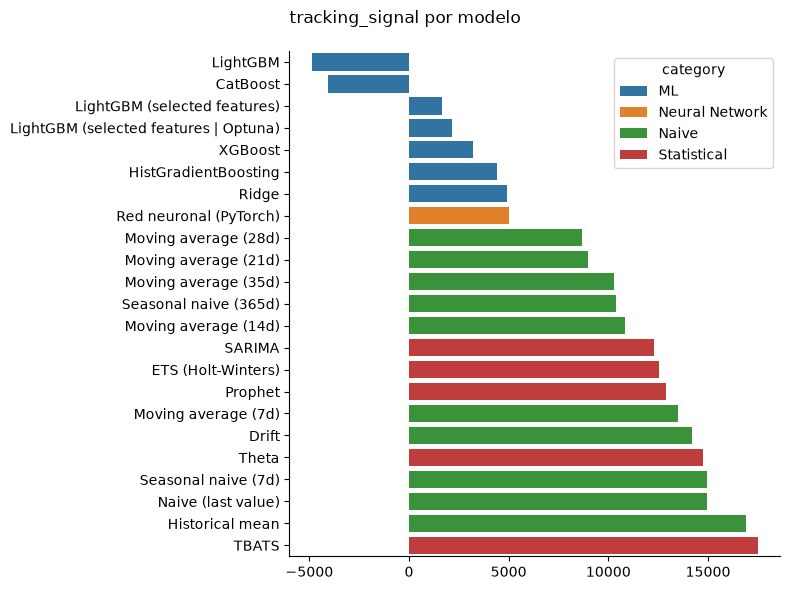

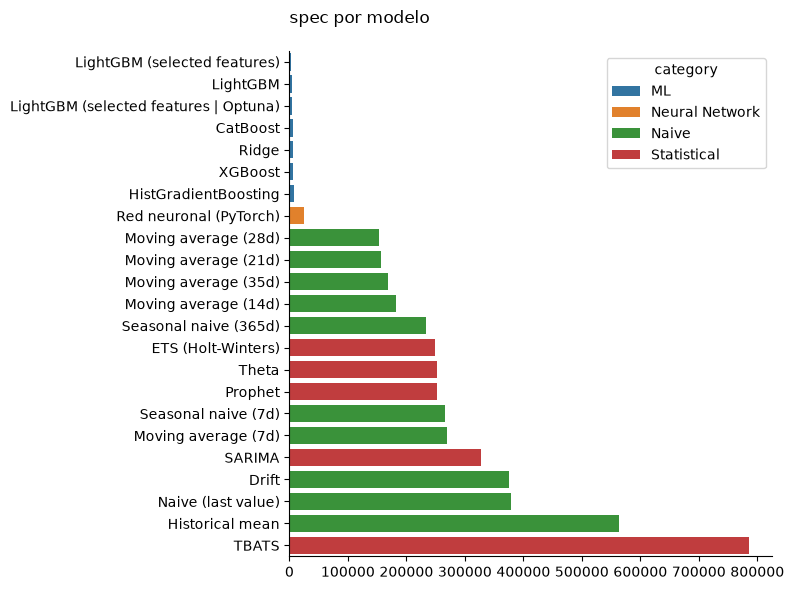

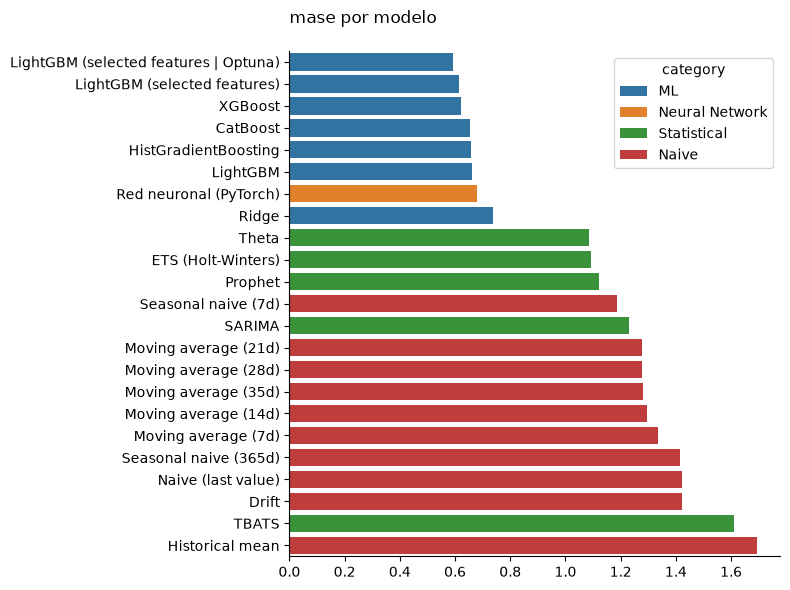

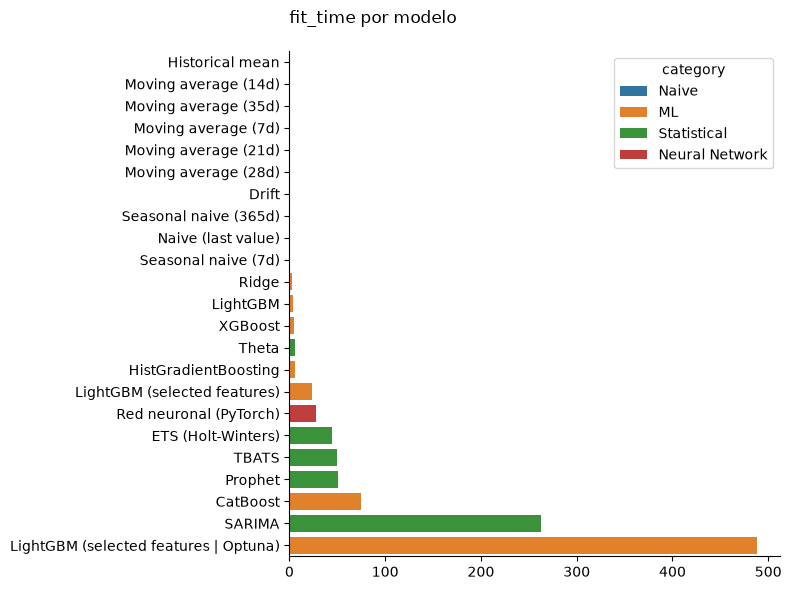

In [24]:
for col in ['wape', 'wrmsse', 'mae', 'rmse', 'mape', 'smape', 'bias', 'rmsle', 'tracking_signal', 'spec', 'mase', 'fit_time']:
    plot_barh_by_model(results_df, hue="category", x=col, y="model", title=f"{col} por modelo")

## Explicación modelo

In [25]:
import shap

explainer = shap.TreeExplainer(model)

X_shap = X_test.sample(n=min(2000, len(X_test)), random_state=42)
shap_values = explainer.shap_values(X_shap)

In [26]:
shap_df = pd.DataFrame(shap_values, columns=X_shap.columns, index=X_shap.index)

importance_df = pd.DataFrame({
    "feature": X_shap.columns,
    "mean_abs_shap": np.abs(shap_values).mean(axis=0),
}).sort_values("mean_abs_shap", ascending=False)

print(importance_df)

                                              feature  mean_abs_shap
10                                               lag1     162.156069
12                                               lag7     113.806629
15                                              lag28      49.184997
6                                           dayofweek      23.785621
11                                               lag2      20.921715
4                                                snap      20.557476
18                    rolling_mean_lag7_window_size14      19.405090
21                    rolling_mean_lag28_window_size7      17.224187
16                     rolling_mean_lag7_window_size7      16.065448
14                                              lag21      12.369517
0                                             dept_id      10.986671
7                                        price_vs_max       9.305901
13                                              lag14       9.207506
3                                 

### Importancia global de features

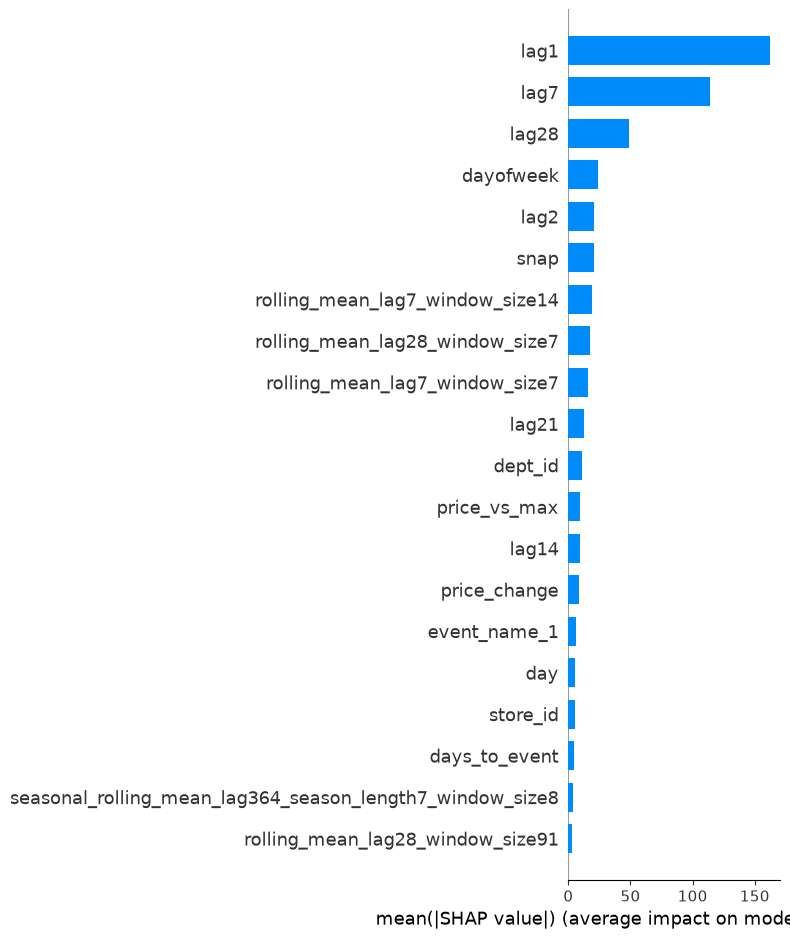

In [27]:
shap.summary_plot(shap_values, X_shap, plot_type="bar")

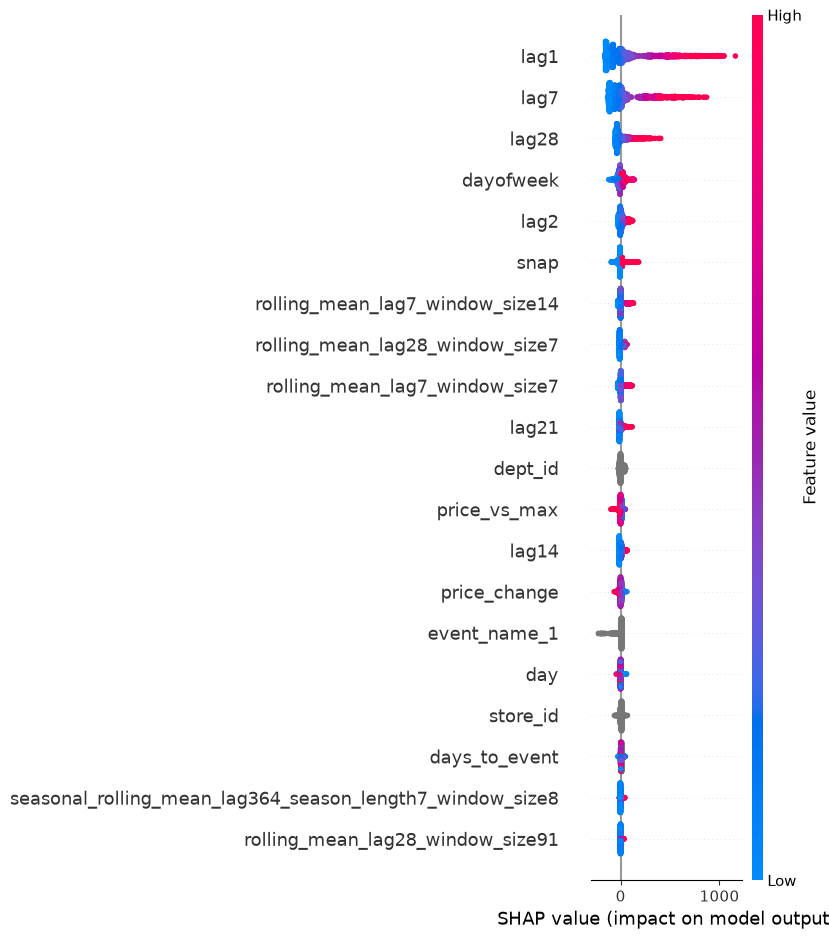

In [28]:
shap.summary_plot(shap_values, X_shap)

### Dependencia por feature

Feature más importante: lag1


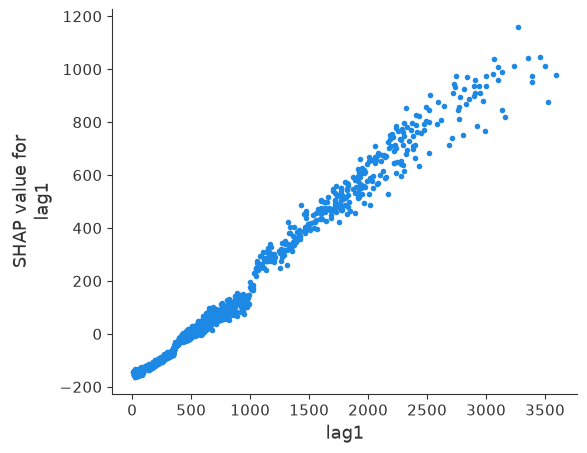

In [29]:
top_feature = X_shap.columns[np.argsort(-np.abs(shap_values).mean(axis=0))[0]]
print(f"Feature más importante: {top_feature}")

shap.dependence_plot(top_feature, shap_values, X_shap, interaction_index=None)

In [30]:
metrics_test_final, df_pred = build_predictions_report(artifact['train'], artifact['test'], y_test, model.predict(X_test), target_col=artifact['target'])

print(f"Test WAPE: {metrics_test_final['wape']:.2%}")
print(f"Test WRMSSE: {metrics_test_final['wrmsse']:.4f}")

Test WAPE: 8.67%
Test WRMSSE: 0.6154


# Predicciones

In [31]:
from src.evaluation import analizar_prediccion as _analizar_prediccion

def analizar_prediccion(agg_id, test=artifact['test'], target=artifact['target'],
                         explainer=explainer, date=None, max_display=10):
    return _analizar_prediccion(
        test, X_test, df_pred, target, agg_id,
        date=date, max_display=max_display, explainer=explainer,
    )

In [ ]:
from src.evaluation.metrics import build_series_metrics

df_metrics = build_series_metrics(artifact['train'], df_pred, target_col=artifact['target'], weight_level=["date"])
df_metrics.head(10)

In [ ]:
df_metrics.head(10)

,n_days,n_days_with_sales,sales,y_pred,error,abs_error,gross_sales,gross_sales_pct,wape,bias,rmsle,tracking_signal,wrmsse,mase,spec
agg_id,,,,,,,,,,,,,,,
FOODS_3_FOODS_CA_3_CA,29,29,80752.0,81876.0,-1124.0,5416.0,203732.281250,0.050132,0.067070,0.013919,0.078912,-6.018464,0.472257,0.500765,270.146552
FOODS_3_FOODS_CA_1_CA,29,29,68989.0,66585.0,2404.0,3048.0,175612.812500,0.043213,0.044181,-0.034846,0.057329,22.872703,0.358326,0.287494,851.353448
HOUSEHOLD_1_HOUSEHOLD_CA_3_CA,29,29,40366.0,41021.0,-655.0,2061.0,171702.140625,0.042251,0.051058,0.016227,0.072221,-9.216400,0.433621,0.462022,56.232759
FOODS_3_FOODS_WI_2_WI,29,29,70371.0,68354.0,2017.0,5671.0,160068.843750,0.039388,0.080587,-0.028662,0.093976,10.314407,0.762179,0.687426,891.775862
FOODS_3_FOODS_CA_2_CA,29,29,59842.0,57332.0,2510.0,4668.0,153737.015625,0.037830,0.078005,-0.041944,0.091986,15.593402,0.761536,0.761406,734.482759
FOODS_3_FOODS_TX_2_TX,29,29,58338.0,58421.0,-83.0,3671.0,140420.406250,0.034553,0.062926,0.001423,0.078554,-0.655680,0.418867,0.391065,66.112069
FOODS_3_FOODS_TX_3_TX,29,29,55285.0,53387.0,1898.0,4660.0,135447.062500,0.033329,0.084290,-0.034331,0.098981,11.811588,0.615932,0.663638,753.525862
FOODS_3_FOODS_WI_3_WI,29,29,60463.0,61903.0,-1440.0,3576.0,135300.671875,0.033293,0.059144,0.023816,0.067473,-11.677852,0.356893,0.371159,270.551724
FOODS_3_FOODS_WI_1_WI,29,29,52107.0,50542.0,1565.0,2749.0,127099.257812,0.031275,0.052757,-0.030034,0.059434,16.509640,0.378393,0.430599,660.465517


In [ ]:
df_pred.query('agg_id == "FOODS_3_FOODS_CA_3_CA"').nlargest(10, 'wape')

,agg_id,date,sales,gross_sales,y_pred,error,abs_error,wape,bias
44635,FOODS_3_FOODS_CA_3_CA,2016-05-15,3496.0,8896.730469,2994.0,502.0,502.0,0.143593,-0.143593
44615,FOODS_3_FOODS_CA_3_CA,2016-04-25,2972.0,7675.609863,2574.0,398.0,398.0,0.133917,-0.133917
44632,FOODS_3_FOODS_CA_3_CA,2016-05-12,2202.0,5538.709961,2487.0,-285.0,285.0,0.129428,0.129428
44623,FOODS_3_FOODS_CA_3_CA,2016-05-03,2655.0,6551.040039,2996.0,-341.0,341.0,0.128437,0.128437
44616,FOODS_3_FOODS_CA_3_CA,2016-04-26,2240.0,5626.109863,2523.0,-283.0,283.0,0.126339,0.126339
44636,FOODS_3_FOODS_CA_3_CA,2016-05-16,2615.0,6564.209961,2923.0,-308.0,308.0,0.117782,0.117782
44642,FOODS_3_FOODS_CA_3_CA,2016-05-22,3573.0,8930.370117,3163.0,410.0,410.0,0.114750,-0.114750
44627,FOODS_3_FOODS_CA_3_CA,2016-05-07,3135.0,7922.120117,3461.0,-326.0,326.0,0.103987,0.103987
44618,FOODS_3_FOODS_CA_3_CA,2016-04-28,2209.0,5390.859863,2435.0,-226.0,226.0,0.102309,0.102309
44629,FOODS_3_FOODS_CA_3_CA,2016-05-09,3238.0,8316.910156,2945.0,293.0,293.0,0.090488,-0.090488


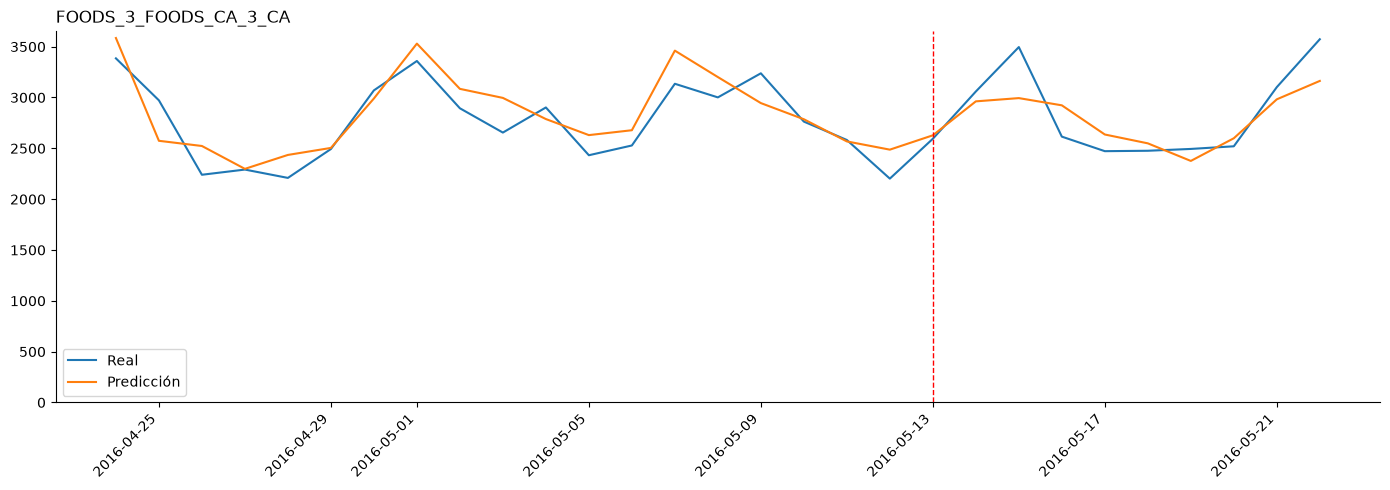

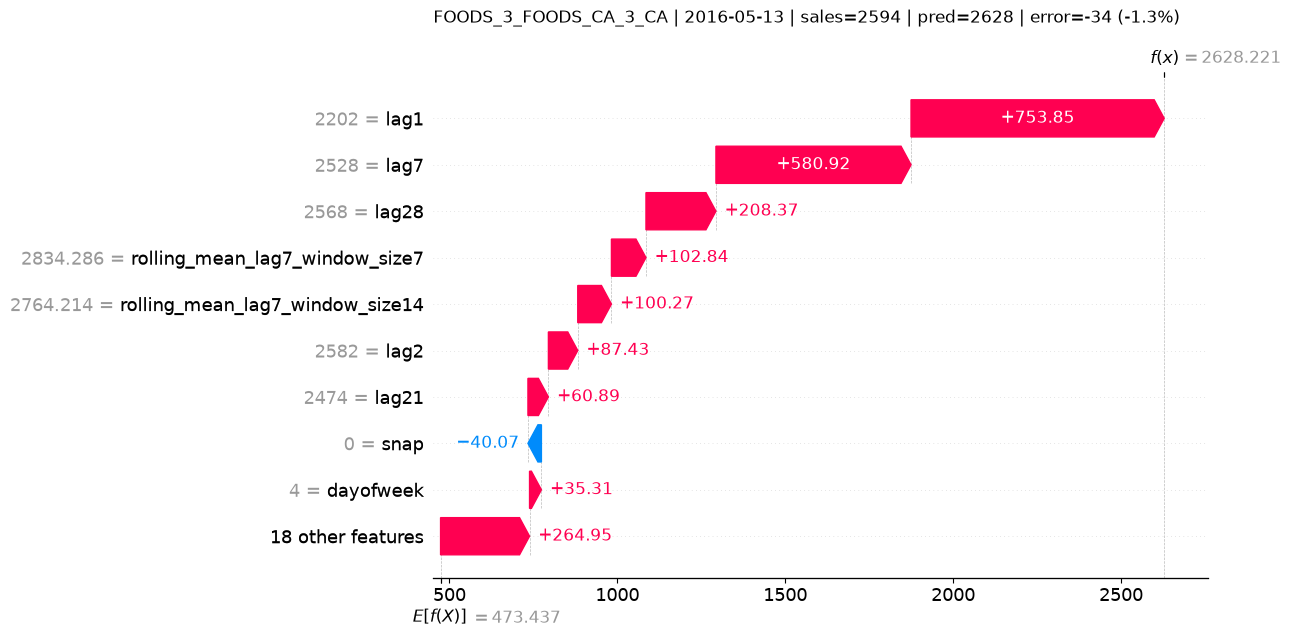

In [ ]:
analizar_prediccion(agg_id='FOODS_3_FOODS_CA_3_CA', date='2016-05-13' )